<a href="https://colab.research.google.com/github/DOHA-BASEM3/FINAL-PROJECT/blob/main/ML_Anomaly_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Course: Machine Learning II
# # Anomaly Detection and Customer Segmentation Using Unsupervised Machine Learning and Deep Learning
# Team Members : Doha ,Ghena, Oraib
# Data set : Credit Card Fraud Detection Dataset

# **1: Data Preprocessing**

# Import Libraries

In [ ]:
# ===============================
# 1. Basic Libraries
# ===============================
import numpy as np
import pandas as pd

# ===============================
# 2. Visualization Libraries
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 3. Preprocessing
# ===============================
from sklearn.preprocessing import RobustScaler

# ===============================
# 4. Dimensionality Reduction
# ===============================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ===============================
# 5. Clustering
# ===============================
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# ===============================
# 6. Anomaly Detection
# ===============================
from sklearn.svm import OneClassSVM

# ===============================
# 7. Model Selection
# ===============================
from sklearn.model_selection import train_test_split

# ===============================
# 8. Evaluation Metrics
# ===============================
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

# ===============================
# 9. Deep Learning - TensorFlow / Keras
# ===============================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ===============================
# 10. Warnings
# ===============================
import warnings
warnings.filterwarnings('ignore')

# ===============================
# 11. Display Settings
# ===============================
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# ===============================
# 12. Random Seed
# ===============================
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Data Loading

In [ ]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ===============================
# Load Dataset
# ===============================

file_path = '/content/drive/MyDrive/ML_Final_Project/creditcard.csv'

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Exploratory Data Analysis (EDA)

In [ ]:
# ===============================
# Dataset Overview
# ===============================

print("Dataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
# ===============================
# Missing Values Check
# ===============================


missing_values = df.isnull().sum().sum()

print(f"Total Missing Values: {missing_values}")

if missing_values == 0:
    print("No missing values found in the dataset.")

Total Missing Values: 0
No missing values found in the dataset.


In [ ]:
# ===============================
# Duplicate Records Check
# ===============================

print("Dataset shape before removing duplicates:", df.shape)

duplicate_count = df.duplicated().sum()
print("Number of duplicated rows:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape before removing duplicates: (284807, 31)
Number of duplicated rows: 1081
Dataset shape after removing duplicates: (283726, 31)


In [ ]:
# ===============================
# Class Distribution
# ===============================

class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

print(f"Normal Transactions : {class_counts[0]} ({class_percentages[0]:.4f}%)")
print(f"Fraud Transactions  : {class_counts[1]} ({class_percentages[1]:.4f}%)")

Normal Transactions : 283253 (99.8333%)
Fraud Transactions  : 473 (0.1667%)


# Data Preprocessing

In [ ]:
# ===============================
# Feature and Target Separation
# ===============================

X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (283726, 30)
Target shape: (283726,)


# Feature Scaling

In [ ]:
# ===============================
# Feature Scaling
# ===============================

# Scale Time and Amount using RobustScaler to reduce the effect of outliers.
# V1-V28 are already transformed, so they are kept unchanged.

scaler = RobustScaler()
X_scaled = X.copy()

X_scaled[['Time', 'Amount']] = scaler.fit_transform(
    X_scaled[['Time', 'Amount']]
)

print("Feature scaling completed successfully!")
print("Scaled feature shape:", X_scaled.shape)

display(X_scaled[['Time', 'Amount']].describe())

Feature scaling completed successfully!
Scaled feature shape: (283726, 30)


,Time,Amount
count,283726.000000,283726.000000
mean,0.118912,0.924387
std,0.557988,3.482123
min,-0.995290,-0.305938
25%,-0.358286,-0.228063
50%,0.000000,0.000000
75%,0.641714,0.771937
max,1.035329,356.962314


In [ ]:
# ===============================
# Verify Preprocessing Output
# ===============================

print("Features Shape:", X_scaled.shape)
print("Target Shape:", y.shape)


print("\nAny missing values after preprocessing?")
print(X_scaled.isnull().sum().sum())

Features Shape: (283726, 30)
Target Shape: (283726,)

Any missing values after preprocessing?
0


**Preprocessing Summary:**  
The preprocessing stage is complete. The dataset has been cleaned, the target variable has been separated, and the features are ready for PCA and anomaly detection models.

# **2: Dimensionality Reduction with PCA**

##Apply PCA

In [ ]:
# ===============================
# Apply PCA
# ===============================

# Apply PCA while preserving 95% of the total variance.
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed successfully!")
print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

print("\nNumber of principal components selected:", pca.n_components_)
print("Total explained variance:", round(np.sum(pca.explained_variance_ratio_), 4))

print("\nExplained variance ratio for each component:")
print(pca.explained_variance_ratio_)

PCA completed successfully!
Original Shape: (283726, 30)
Reduced Shape: (283726, 22)

Number of principal components selected: 22
Total explained variance: 0.9579

Explained variance ratio for each component:
[0.32689767 0.08604632 0.05634564 0.05229584 0.04650542 0.04198303
 0.03824846 0.03246825 0.02808536 0.02716703 0.02481647 0.02327759
 0.02308241 0.0212641  0.01976632 0.01888398 0.01780283 0.01662688
 0.01625591 0.01536074 0.01252552 0.01224194]


**PCA Summary:**  
After applying PCA, we found that the feature space was reduced from 30 original features to 22 principal components while preserving approximately 95.79% of the total variance. This means that most of the important information was retained, and the reduced representation can be used in the next stages to improve efficiency and reduce dimensionality.

##  Variance Analysis Plot

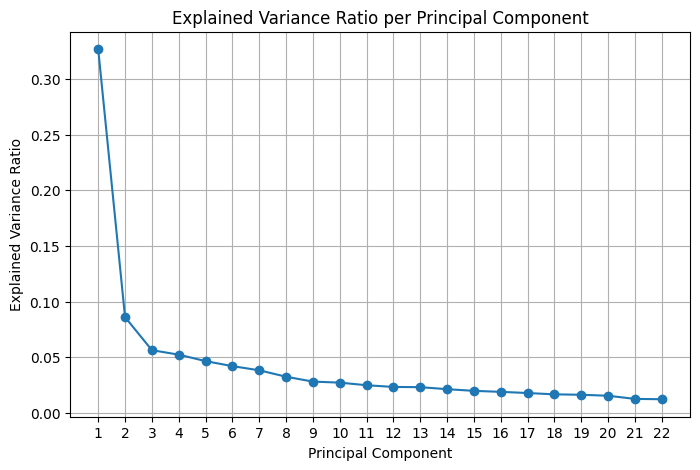

In [ ]:
# ===============================
# Explained Variance Ratio Plot
# ===============================

# This plot shows how much variance is explained by each principal component individually.

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.title("Explained Variance Ratio per Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(True)

plt.show()

**Explained Variance Ratio:**  
This plot shows how much variance is explained by each principal component individually. We observed that the first few components explain the largest portion of the variance, while later components contribute less information.

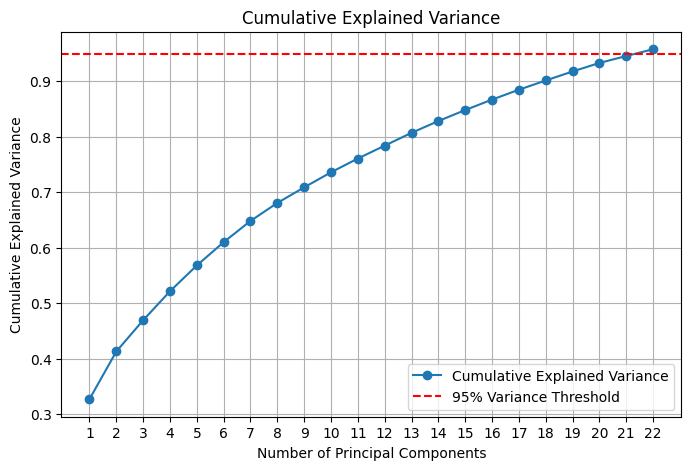

In [ ]:
# ===============================
# Cumulative Explained Variance Plot
# ===============================

# Calculate cumulative explained variance to determine
# how many principal components are needed to preserve 95% of the variance.
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o',
    label='Cumulative Explained Variance'
)

plt.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='95% Variance Threshold'
)

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)
plt.legend()
plt.show()

**Cumulative Variance Analysis:**  
This plot shows how the explained variance increases as more principal components are added. We observed that 22 principal components are enough to preserve approximately 95.79% of the total variance, confirming that PCA reduced dimensionality while retaining most of the important information.

## PCA Visualization

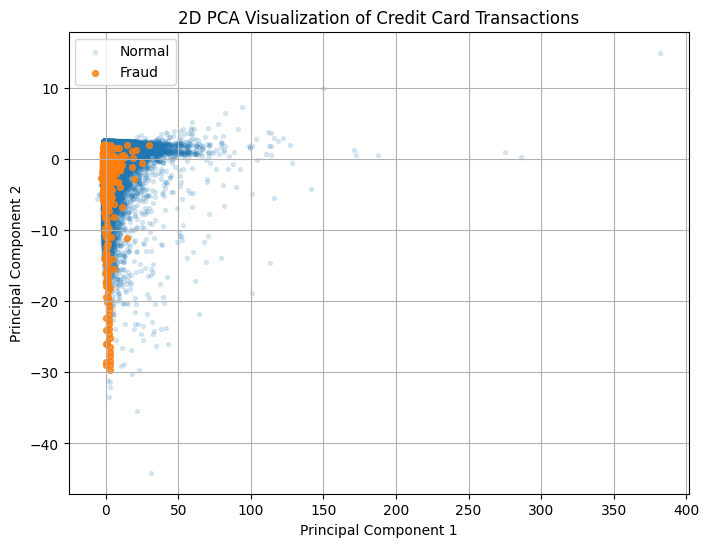

In [ ]:
# ===============================
# PCA 2D Visualization
# ===============================

# Apply PCA with 2 components only for visualization.
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

# Plot normal transactions
plt.scatter(
    X_pca_2d[y == 0, 0],
    X_pca_2d[y == 0, 1],
    alpha=0.15,
    s=8,
    label='Normal'
)

# Plot fraud transactions
plt.scatter(
    X_pca_2d[y == 1, 0],
    X_pca_2d[y == 1, 1],
    alpha=0.8,
    s=18,
    label='Fraud'
)

plt.title("2D PCA Visualization of Credit Card Transactions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend()
plt.show()

**PCA Visualization Insight:**  
The 2D PCA plot shows a strong overlap between normal and fraudulent transactions. This suggests that the first two principal components are not sufficient to clearly separate fraud cases, so further visualization and anomaly detection techniques are needed.

# **3: Data Visualization with t-SNE**

##Apply t-SNE

In [ ]:
# ===============================
# Prepare Sample for t-SNE
# ===============================

# t-SNE is computationally expensive, so we use a sampled subset.
# To better visualize fraud cases, we include all fraud transactions
# and a random sample of normal transactions.

fraud_df = df[df['Class'] == 1]
normal_df = df[df['Class'] == 0].sample(n=5000, random_state=RANDOM_STATE)

sample_df = pd.concat([normal_df, fraud_df]).sample(frac=1, random_state=RANDOM_STATE)

X_sample = X_pca[sample_df.index]
y_sample = sample_df['Class']

print("t-SNE sample shape:", X_sample.shape)
print("Class distribution in t-SNE sample:")
print(y_sample.value_counts())

t-SNE sample shape: (5473, 22)
Class distribution in t-SNE sample:
Class
0    5000
1     473
Name: count, dtype: int64


In [ ]:
# ===============================
# Apply t-SNE
# ===============================

# Apply t-SNE to reduce the PCA-transformed sample into 2 dimensions.
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    random_state=RANDOM_STATE
)

X_tsne = tsne.fit_transform(X_sample)

print("t-SNE completed successfully!")
print("t-SNE output shape:", X_tsne.shape)

t-SNE completed successfully!
t-SNE output shape: (5473, 2)


## 2D t-SNE Visualization

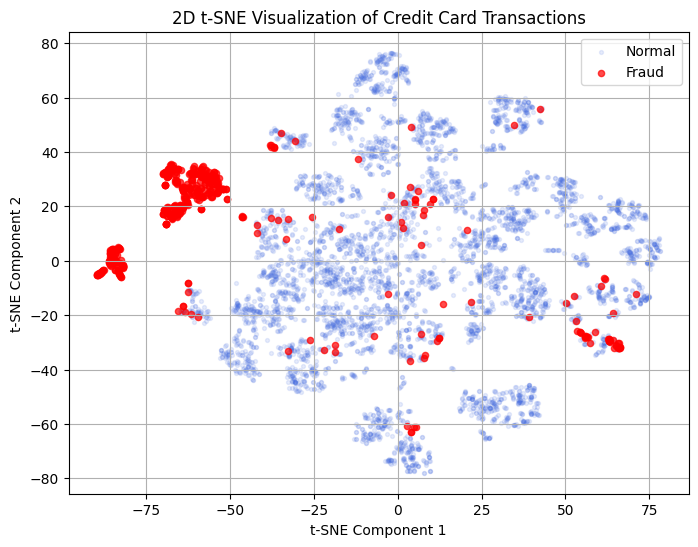

In [ ]:
# ===============================
# 2D t-SNE Visualization
# ===============================

# Visualize the t-SNE result to compare normal and fraud transactions.
plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[y_sample == 0, 0],
    X_tsne[y_sample == 0, 1],
    c='royalblue',
    alpha=0.12,
    s=8,
    label='Normal'
)

plt.scatter(
    X_tsne[y_sample == 1, 0],
    X_tsne[y_sample == 1, 1],
    c='red',
    alpha=0.70,
    s=20,
    label='Fraud'
)

plt.title("2D t-SNE Visualization of Credit Card Transactions")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.legend()
plt.show()

**t-SNE Visualization Insight:**  
The t-SNE plot shows that some fraudulent transactions appear in small separated regions, while others still overlap with normal transactions. This indicates that fraud patterns are not fully separable using visualization alone. Therefore, anomaly detection models such as DBSCAN, One-Class SVM, and deep learning are needed to better identify suspicious transactions.



---



# **4: Clustering with DBSCAN**

## Apply DBSCAN

In [ ]:
# ==============================
# PCA Dimensionality Reduction
# ==============================

# Apply PCA to reduce data dimensionality
# 10 principal components are used to improve DBSCAN efficiency
pca_final = PCA(n_components=10, random_state=RANDOM_STATE)

X_pca_final = pca_final.fit_transform(X_scaled)

print("PCA-reduced data shape :", X_pca_final.shape)

print("Explained variance:", round(pca_final.explained_variance_ratio_.sum(), 3))


PCA-reduced data shape : (283726, 10)
Explained variance: 0.736


**PCA Insight:**
PCA reduced the dataset from 30 features to 10 principal components while retaining most of the important information. This reduced data complexity and helped DBSCAN identify more compact and well-separated clusters with fewer noise points.

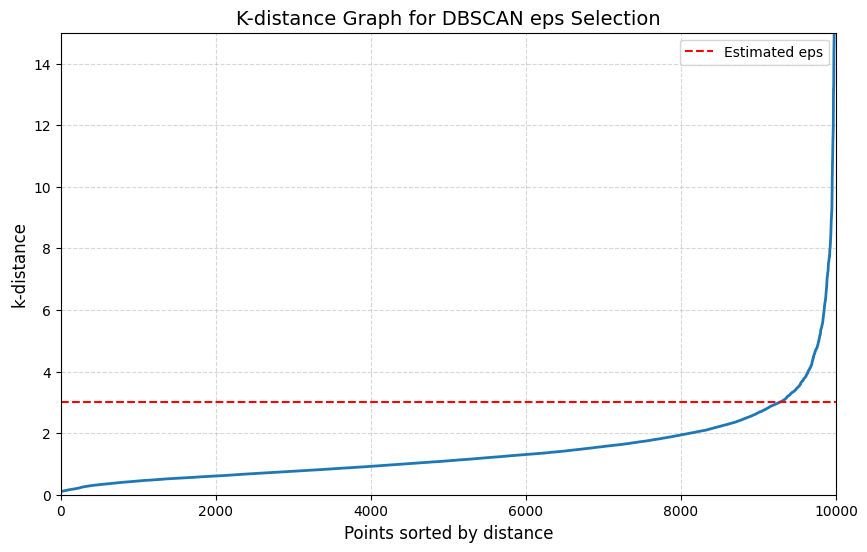

Fraud ratio in full dataset: 0.001667
Fraud ratio in 10000 sample: 0.0017


In [ ]:
# ==========================================
# K-distance Graph for DBSCAN eps Selection
# ==========================================

# Create a stratified sample of 10,000 records
# to reduce computation time while preserving the fraud ratio

X_tuning_sample, _, y_tuning_sample, _ = train_test_split(
    X_pca_final,
    y,
    train_size=10000,
    stratify=y,
    random_state=42)

# Set min_samples for DBSCAN neighborhood calculation
min_samples = 10


# Compute nearest neighbors distances
neighbors = NearestNeighbors(
    n_neighbors=min_samples,
    algorithm='ball_tree'
)

neighbors_fit = neighbors.fit(X_tuning_sample)

# Calculate distances to nearest neighbors & # Sort distances for elbow point visualization

distances, indices = neighbors_fit.kneighbors(X_tuning_sample)

distances = np.sort(distances[:, -1])


# Plot K-distance Graph

plt.figure(figsize=(10,6))
plt.plot(distances, linewidth=2)
plt.xlabel("Points sorted by distance", fontsize=12)
plt.ylabel("k-distance", fontsize=12)
plt.title("K-distance Graph for DBSCAN eps Selection", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, len(distances))
plt.ylim(0, 15)
plt.axhline(y=3, color='red', linestyle='--', label='Estimated eps')
plt.legend()
plt.show()


# Fraud Ratio Comparison

full_fraud_ratio = y.mean()
sample_fraud_ratio =y_tuning_sample.mean()
print("Fraud ratio in full dataset:",
      round(full_fraud_ratio, 6))

print("Fraud ratio in 10000 sample:",
      round(sample_fraud_ratio, 6))

**k-distance Insight:**
The k-distance graph was used to estimate a suitable eps value for DBSCAN. A stratified sample of 10,000 transactions was used to reduce computation time while preserving the fraud ratio. The elbow region appears around eps ≈ 3, so nearby eps values were tested during parameter tuning.

In [ ]:
# ==============================
# DBSCAN Parameter Tuning
# ==============================

# Use the same tuning sample from the K-distance graph
# X_tuning_sample
# y_tuning_sample

# Candidate eps values & min_samples values
eps_values = [2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3]
min_samples_values = [5,10]

results = []

# Test different DBSCAN parameter combinations
for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=-1 )
        labels = dbscan.fit_predict(X_tuning_sample)
        n_noise = np.sum(labels == -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_percentage = (n_noise / len(labels)) * 100

        mask = labels != -1

        if n_clusters > 1 and len(set(labels[mask])) > 1:
            silhouette = silhouette_score(
                X_tuning_sample[mask],
                labels[mask]
            )

            davies_bouldin = davies_bouldin_score(
                X_tuning_sample[mask],
                labels[mask]
            )
        else:
            silhouette = np.nan
            davies_bouldin = np.nan
   # Store parameter tuning results
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "noise_percentage": round(noise_percentage, 2),
            "silhouette_score": round(silhouette, 4) if not np.isnan(silhouette) else np.nan,
            "davies_bouldin_score": round(davies_bouldin, 4) if not np.isnan(davies_bouldin) else np.nan
        })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["silhouette_score", "davies_bouldin_score"],
    ascending=[False, True],
    na_position="last"
)
# Display tuning sample information
print("Tuning sample shape:", X_tuning_sample.shape)
print("Fraud ratio in tuning sample:",
      round(y_tuning_sample.mean(), 4))

# Display parameter tuning results
display(results_df)

Tuning sample shape: (10000, 10)
Fraud ratio in tuning sample: 0.0017


,eps,min_samples,clusters,noise_points,noise_percentage,silhouette_score,davies_bouldin_score
12,3.3,5,2,296,2.96,0.8062,0.2053
7,3.0,10,3,420,4.20,0.7177,1.3287
5,2.9,10,3,466,4.66,0.7055,0.9087
8,3.1,5,3,335,3.35,0.6512,0.3402
10,3.2,5,3,313,3.13,0.6451,0.3184
4,2.9,5,3,389,3.89,0.5246,0.4199
6,3.0,5,4,352,3.52,0.5113,0.4255
2,2.8,5,3,425,4.25,0.4205,0.6199
0,2.7,5,3,470,4.70,0.3610,0.6785
1,2.7,10,1,603,6.03,NaN,NaN


**Parameter Tuning Insight:**
Different eps and min_samples values were tested to identify the best DBSCAN configuration. The parameters were evaluated using Silhouette Score, Davies-Bouldin Index, number of clusters, and noise percentage. The best results were achieved with eps = 3.3 and min_samples = 5, which produced clearer cluster separation and lower noise.

In [ ]:
# ===============================
# Prepare Final Sample for DBSCAN
# ===============================


# Create a larger stratified sample for the final DBSCAN application
# This balances computational efficiency with result reliability
RANDOM_STATE = 42

final_sample_indices, _, y_final_sample, _ = train_test_split(
    df.index,
    y,
    train_size=30000,
    stratify=y,
    random_state=RANDOM_STATE)



# Fraud Ratio Comparison

print("Sample size:", len(final_sample_indices))
print("Fraud ratio in full dataset:",
      round(full_fraud_ratio, 4))
print("Fraud ratio in sample:",
      round(y_final_sample.mean(), 4))

# Prepare Datasets

X_before_pca_sample = X_scaled.loc[final_sample_indices]

X_after_pca_sample = X_pca_final[final_sample_indices]

y_dbscan_sample = y.loc[final_sample_indices]

# Shapes
print("\nOriginal scaled data shape before PCA:",
      X_before_pca_sample.shape)

print("PCA-reduced data shape with 10 components:",
      X_after_pca_sample.shape)

Sample size: 30000
Fraud ratio in full dataset: 0.0017
Fraud ratio in sample: 0.0017

Original scaled data shape before PCA: (30000, 30)
PCA-reduced data shape with 10 components: (30000, 10)


**Final Sample Insight:**
A larger stratified sample of 30,000 transactions was prepared for the final DBSCAN comparison. The same sample indices were used before and after PCA to ensure a fair comparison while preserving the original fraud ratio.

In [ ]:
# ==============================
# Final DBSCAN Application
# ==============================

# Apply DBSCAN using the selected tuning parameters
# Compare clustering results before and after PCA
best_eps = 3.3
best_min_samples = 5

results = []

# ---------- DBSCAN without PCA ----------

# Apply DBSCAN on scaled data before PCA
dbscan_final = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    n_jobs=-1)

labels_before_pca = dbscan_final.fit_predict(X_before_pca_sample)

# Count noise points
n_noise = np.sum(labels_before_pca == -1)

# Count clusters excluding noise
n_clusters = len(set(labels_before_pca)) - (
        1 if -1 in labels_before_pca else 0)
noise_percentage = (n_noise / len(labels_before_pca)) * 100

# Exclude noise points for evaluation
mask = labels_before_pca != -1

# Calculate clustering evaluation metrics
silhouette = silhouette_score(
    X_before_pca_sample[mask],
    labels_before_pca[mask])

davies_bouldin = davies_bouldin_score(
    X_before_pca_sample[mask],
    labels_before_pca[mask]
)

# Store results before PCA
results.append({
    "method": "DBSCAN without PCA",
    "eps": best_eps,
    "min_samples": best_min_samples,
    "clusters": n_clusters,
    "noise_points": n_noise,
    "noise_percentage": round(noise_percentage, 2),
    "silhouette_score": round(silhouette, 4),
    "davies_bouldin_score": round(davies_bouldin, 4)
})

# ---------- DBSCAN with PCA ----------

# Apply DBSCAN on PCA-reduced data
dbscan_final = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    n_jobs=-1
)

labels_after_pca = dbscan_final.fit_predict(X_after_pca_sample)

# Count noise points
n_noise = np.sum(labels_after_pca == -1)

# Count clusters excluding noise
n_clusters = len(set(labels_after_pca)) - (
    1 if -1 in labels_after_pca else 0
)

# Calculate noise percentage
noise_percentage = (n_noise / len(labels_after_pca)) * 100

# Exclude noise points for evaluation
mask = labels_after_pca != -1

# Calculate clustering evaluation metrics
silhouette = silhouette_score(
    X_after_pca_sample[mask],
    labels_after_pca[mask]
)

davies_bouldin = davies_bouldin_score(
    X_after_pca_sample[mask],
    labels_after_pca[mask]
)

# Store results after PCA
results.append({
    "method": "DBSCAN with PCA",
    "eps": best_eps,
    "min_samples": best_min_samples,
    "clusters": n_clusters,
    "noise_points": n_noise,
    "noise_percentage": round(noise_percentage, 2),
    "silhouette_score": round(silhouette, 4),
    "davies_bouldin_score": round(davies_bouldin, 4)
})

# Convert results into a comparison DataFrame
comparison_df = pd.DataFrame(results)

# Display final comparison results
comparison_df

,method,eps,min_samples,clusters,noise_points,noise_percentage,silhouette_score,davies_bouldin_score
0,DBSCAN without PCA,3.3,5,22,2801,9.34,0.0415,1.3028
1,DBSCAN with PCA,3.3,5,4,575,1.92,0.6660,0.6302


## Cluster Visualization

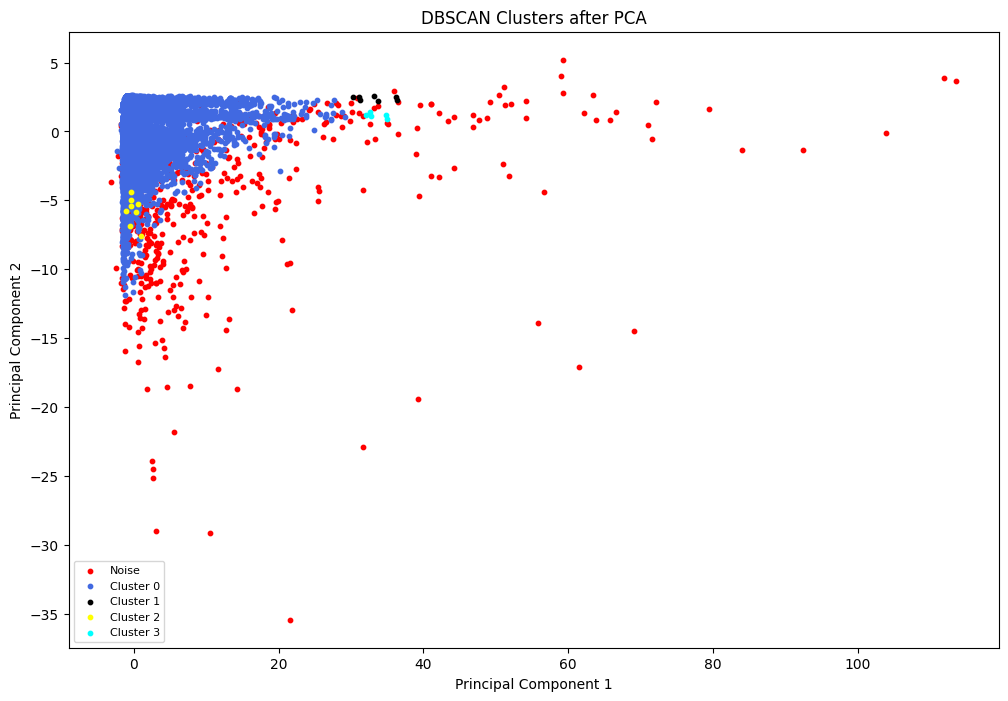

(30000, 10)


In [ ]:
# ===============================
# DBSCAN Cluster Visualization
# ===============================

# Use the first two PCA components for visualization
X_pca_2d = X_after_pca_sample[:, :2]
plt.figure(figsize=(12,8))

# Get unique cluster labels
unique_labels = np.unique(labels_after_pca)

# Plot each cluster separately
for label in unique_labels:

    if label == -1:
        color = "red"
        label_name = "Noise"

    elif label == 0:
        color ="royalblue"
        label_name = "Cluster 0"

    elif label == 1:
        color = "black"
        label_name = "Cluster 1"

    elif label == 2:
        color = "yellow"
        label_name = "Cluster 2"

    elif label == 3:
        color =  "cyan"
        label_name = "Cluster 3"

    else:
        color = "darkturquoise"
        label_name = f"Cluster {label}"

# Plot cluster points
    plt.scatter(
        X_pca_2d[labels_after_pca == label, 0],
        X_pca_2d[labels_after_pca == label, 1],
        s=10,
        c=color,
        label=label_name
    )
plt.title("DBSCAN Clusters after PCA")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(fontsize=8)
plt.show()
print(X_after_pca_sample.shape)

**DBSCAN Visualization Insight:**
The PCA-based DBSCAN visualization shows one large dense cluster representing the majority of normal transactions, while isolated points were detected as noise or anomalous patterns. Several small additional clusters were also identified, indicating less common transaction behaviors. Overall, PCA helped improve cluster separation and enhanced the detection of unusual transaction regions.

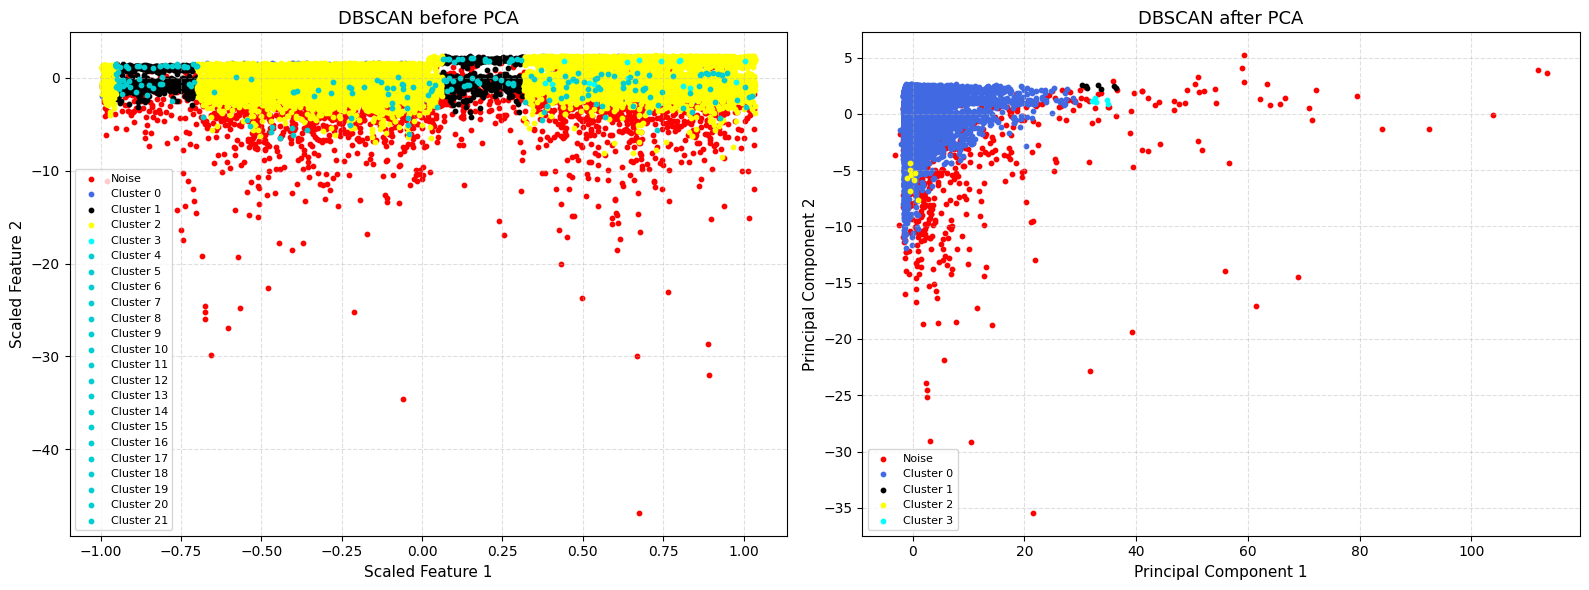

In [ ]:
# ==========================================
# DBSCAN Visualization Before and After PCA
# ==========================================

def plot_dbscan_clusters(X_2d, labels, title, xlabel, ylabel, xlim=None, ylim=None):
    # Get unique DBSCAN labels
    unique_labels = np.unique(labels)

    # Plot each cluster separately
    for label in unique_labels:

        if label == -1:
            color = "red"
            label_name = "Noise"
        elif label == 0:
            color = "royalblue"
            label_name = "Cluster 0"
        elif label == 1:
            color = "black"
            label_name = "Cluster 1"
        elif label == 2:
            color = "yellow"
            label_name = "Cluster 2"
        elif label == 3:
            color = "cyan"
            label_name = "Cluster 3"
        else:
            color = "darkturquoise"
            label_name = f"Cluster {label}"

        # Plot points for the current cluster
        plt.scatter(
            X_2d[labels == label, 0],
            X_2d[labels == label, 1],
            s=10,
            c=color,
            label=label_name
        )

    # Add title and axis labels
    plt.title(title, fontsize=13)
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)

    # Apply zoom limits if provided
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

    plt.legend(fontsize=8)
    plt.grid(True, linestyle="--", alpha=0.4)

# Prepare 2D data before PCA using the first two scaled features
X_before_2d = X_before_pca_sample.iloc[:, :2].values
# Prepare 2D data after PCA using the first two principal components
X_after_2d = X_after_pca_sample[:, :2]
plt.figure(figsize=(16, 6))

# DBSCAN before PCA
plt.subplot(1, 2, 1)
plot_dbscan_clusters(
    X_before_2d,
    labels_before_pca,
    "DBSCAN before PCA",
    "Scaled Feature 1",
    "Scaled Feature 2")
# DBSCAN after PCA
plt.subplot(1, 2, 2)
plot_dbscan_clusters(
    X_after_2d,
    labels_after_pca,
    "DBSCAN after PCA",
    "Principal Component 1",
    "Principal Component 2"
)
plt.tight_layout()
plt.show()

## Evaluation

**Silhouette Score
&
Davies-Bouldin Index**

In [ ]:
# ==============================
# DBSCAN Evaluation
# ==============================

# Exclude noise points from evaluation
mask = labels_after_pca != -1
# Check if at least two clusters remain
if len(np.unique(labels_after_pca[mask])) > 1:

    # Calculate Silhouette Score
    silhouette_no_noise = silhouette_score(
        X_after_pca_sample[mask],
        labels_after_pca[mask]
    )

    # Calculate Davies-Bouldin Index
    davies_bouldin_no_noise = davies_bouldin_score(
        X_after_pca_sample[mask],
        labels_after_pca[mask])
    # Display evaluation results
    print("DBSCAN Evaluation without Noise Points")
    print("-" * 40)

    print("Silhouette Score:",
          round(silhouette_no_noise, 4))

    print("Davies-Bouldin Index:",
          round(davies_bouldin_no_noise, 4))

else:
    print(
        "Evaluation cannot be computed because fewer than "
        "two clusters remain after removing noise.")

DBSCAN Evaluation without Noise Points
----------------------------------------
Silhouette Score: 0.666
Davies-Bouldin Index: 0.6302


**DBSCAN Evaluation Insight:**
The evaluation results indicate that DBSCAN achieved good clustering performance after applying PCA. The Silhouette Score of 0.666 suggests better cluster separation and cohesion, while the low Davies-Bouldin Index of 0.6302 indicates more compact and well-separated clusters. Noise points were excluded from the evaluation to measure the quality of the formed clusters more accurately.

**Cluster Distribution**

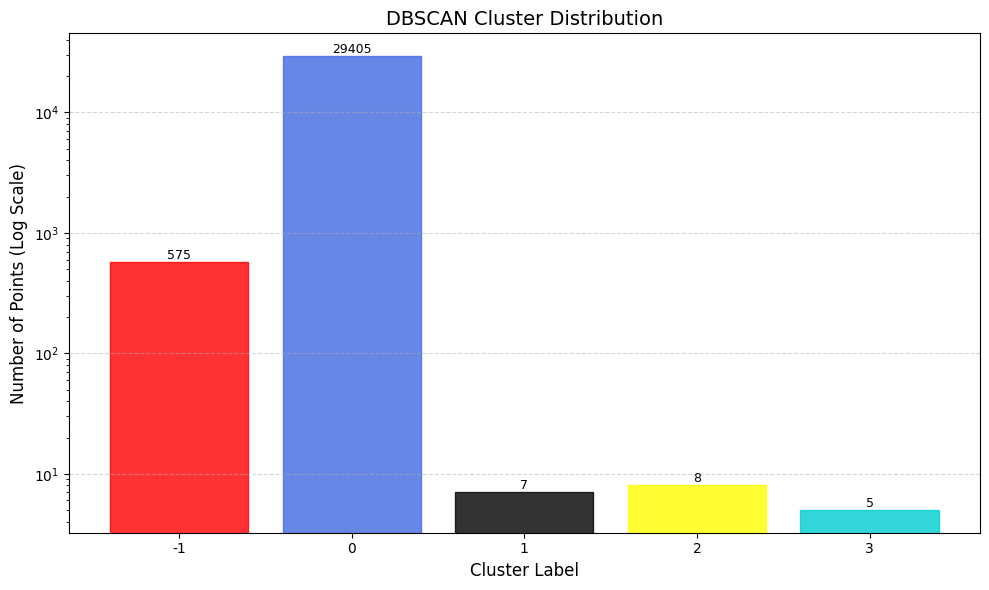

In [ ]:
# ==============================
# Cluster Distribution
# ==============================

# Count points in each cluster
cluster_distribution = pd.Series(
    labels_after_pca
).value_counts().sort_index()

plt.figure(figsize=(10, 6))

bars = plt.bar(
    cluster_distribution.index.astype(str),
    cluster_distribution.values,
    edgecolor="black",
    alpha=0.8)
# Cluster colors
colors = [
    "red",          # Noise
    "royalblue",    # Cluster 0
    "black",        # Cluster 1
    "yellow",         # Cluster 2
    "darkturquoise" # Cluster 3
    ]

for bar, color in zip(bars, colors):
    bar.set_color(color)

# Plot formatting
plt.title("DBSCAN Cluster Distribution",
          fontsize=14)

plt.xlabel("Cluster Label",
           fontsize=12)
plt.ylabel("Number of Points (Log Scale)",
           fontsize=12)
plt.yscale("log")
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5)

# Display values on bars
for bar in bars:

    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**DBSCAN Cluster Distribution Insight:**
The cluster distribution shows that the majority of transactions belong to one dominant dense cluster, while 575 transactions were identified as noise or anomalous points. Several very small clusters were also detected, representing less common transaction behaviors. The logarithmic scale was used to clearly visualize the large difference in cluster sizes.

# **5: Anomaly Detection Using One-Class SVM**

## Train One-Class SVM

In [ ]:
# ==============================
# Prepare Sample for One-Class SVM
# ==============================

# One-Class SVM is computationally expensive,
# so we use stratified sampling while preserving
# the original fraud ratio.

sample_size = 40000

# Create DataFrame from PCA features
sample_df = pd.DataFrame(X_pca)

# Add target labels
sample_df["Class"] = y.values

# Perform stratified sampling
ocsvm_sample = sample_df.groupby(
    "Class",
    group_keys=False
).apply(
    lambda x: x.sample(
        n=min(len(x), int(sample_size * len(x) / len(sample_df))),
        random_state=RANDOM_STATE))

# Separate features and labels
X_ocsvm = ocsvm_sample.drop("Class", axis=1).values
y_ocsvm = ocsvm_sample["Class"].values

# Calculate class distribution
class_distribution = pd.Series(y_ocsvm).value_counts()

fraud_count = np.sum(y_ocsvm == 1)
normal_count = np.sum(y_ocsvm == 0)

fraud_ratio_sample = (fraud_count / len(y_ocsvm)) * 100

# Display sample summary
print("One-Class SVM Sample Summary")
print("-" * 35)

print("Sample shape:", X_ocsvm.shape)

print("\nClass Distribution")
print("-" * 35)
print(class_distribution)

print("\nFraud Analysis")
print("-" * 35)
print("Normal transactions:", normal_count)
print("Fraud transactions :", fraud_count)
print(f"Fraud ratio: {fraud_ratio_sample:.4f}%")

One-Class SVM Sample Summary
-----------------------------------
Sample shape: (39999, 22)

Class Distribution
-----------------------------------
0    39933
1       66
Name: count, dtype: int64

Fraud Analysis
-----------------------------------
Normal transactions: 39933
Fraud transactions : 66
Fraud ratio: 0.1650%


A stratified sample of 40,000 transactions was created to reduce computational cost while preserving the original fraud ratio in the dataset.

The sample contained 39,933 normal transactions and 66 fraud transactions, resulting in a fraud ratio of approximately 0.165%, which is close to the original dataset distribution.

In [ ]:
# ==============================
# Train-Test Split for One-Class SVM
# ==============================

# Split the sampled data while preserving the fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_ocsvm,
    y_ocsvm,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_ocsvm)

# Keep only normal transactions for training
# One-Class SVM learns the normal behavior only
X_train_normal = X_train[y_train == 0]

# Calculate class distribution
train_fraud_count = np.sum(y_train == 1)
test_fraud_count = np.sum(y_test == 1)

train_fraud_ratio = (train_fraud_count / len(y_train)) * 100
test_fraud_ratio = (test_fraud_count / len(y_test)) * 100

# Display split summary
print("Train-Test Split Summary")
print("-" * 35)

print("Training samples before filtering:", X_train.shape)
print("Training normal samples:", X_train_normal.shape)
print("Testing samples:", X_test.shape)

print("\nClass Distribution")
print("-" * 35)
print("Fraud cases in training set:", train_fraud_count)
print(f"Fraud ratio in training set: {train_fraud_ratio:.4f}%")

print("Fraud cases in test set:", test_fraud_count)
print(f"Fraud ratio in test set: {test_fraud_ratio:.4f}%")

Train-Test Split Summary
-----------------------------------
Training samples before filtering: (27999, 22)
Training normal samples: (27953, 22)
Testing samples: (12000, 22)

Class Distribution
-----------------------------------
Fraud cases in training set: 46
Fraud ratio in training set: 0.1643%
Fraud cases in test set: 20
Fraud ratio in test set: 0.1667%


The sampled data was divided into 70% training and 30% testing while preserving the fraud distribution using stratified sampling.

Only normal transactions were used for training because One-Class SVM is an anomaly detection model that learns the normal behavior pattern and later identifies unusual transactions as anomalies.

In [ ]:
# ==============================
# Train One-Class SVM
# ==============================

# One-Class SVM is trained only on normal transactions
# to learn the boundary of normal behavior.

nu=0.001
gamma=0.005
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma=gamma,
    nu=nu
)

ocsvm.fit(X_train_normal)
# Train the model using only normal transactions
ocsvm.fit(X_train_normal)

# Display training summary
print("One-Class SVM Training Summary")
print("-" * 35)

print("Kernel type :", "RBF")
print("Gamma        :",gamma )
print("Nu parameter :", nu)
print("\nTraining completed successfully.")

One-Class SVM Training Summary
-----------------------------------
Kernel type : RBF
Gamma        : 0.005
Nu parameter : 0.001

Training completed successfully.


The One-Class SVM model was trained using an RBF kernel with tuned parameters (`nu = 0.001` and `gamma = 0.005`).

These parameters were selected after experimentation to improve the balance between precision and recall while reducing false positives.

## Predict Anomalies

In [ ]:
# ==============================
# Predict Anomalies using One-Class SVM
# ==============================

# One-Class SVM outputs:
#  1  -> normal
# -1  -> anomaly

y_pred_raw = ocsvm.predict(X_test)

# Convert predictions to binary labels:
# 0 -> normal
# 1 -> fraud/anomaly

y_pred = np.where(y_pred_raw == -1, 1, 0)

# Calculate prediction statistics
detected_anomalies = np.sum(y_pred == 1)
actual_fraud_cases = np.sum(y_test == 1)

predicted_distribution = pd.Series(y_pred).value_counts()
actual_distribution = pd.Series(y_test).value_counts()

# Display prediction summary
print("One-Class SVM Prediction Summary")
print("-" * 40)

print("Detected anomalies :", detected_anomalies)
print("Actual fraud cases :", actual_fraud_cases)

print("\nPredicted Class Distribution")
print("-" * 40)
print(predicted_distribution)

print("\nActual Class Distribution")
print("-" * 40)
print(actual_distribution)

One-Class SVM Prediction Summary
----------------------------------------
Detected anomalies : 58
Actual fraud cases : 20

Predicted Class Distribution
----------------------------------------
0    11942
1       58
Name: count, dtype: int64

Actual Class Distribution
----------------------------------------
0    11980
1       20
Name: count, dtype: int64


The trained One-Class SVM model was used to predict anomalies in the test set.

The model detected 58 anomalous transactions, while the actual number of fraud cases in the test set was 20. This indicates that the model was able to identify suspicious patterns, although some normal transactions were also classified as anomalies.

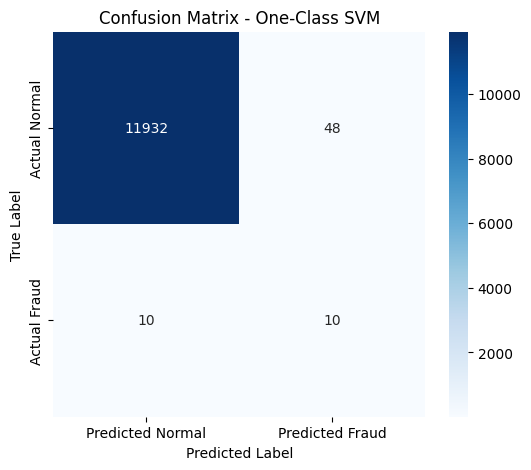

In [ ]:
# ==============================
# Confusion Matrix Visualization
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Fraud'],
    yticklabels=['Actual Normal', 'Actual Fraud']
)

plt.title("Confusion Matrix - One-Class SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrix shows that the model correctly classified most normal transactions while successfully detecting 10 fraud cases.

However, 48 normal transactions were incorrectly classified as fraud (false positives), and 10 fraud transactions were missed (false negatives). This reflects the trade-off between fraud detection sensitivity and false alarm reduction in anomaly detection models.

## Performance Analysis

**Recall**  & **F1-Score**

In [ ]:
# ==============================
# One-Class SVM Evaluation
# ==============================

# Generate classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Fraud"]
)

print("\nClassification Report")
print("-" * 40)
print(report)


Classification Report
----------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     11980
       Fraud       0.19      0.65      0.30        20

    accuracy                           0.99     12000
   macro avg       0.60      0.82      0.65     12000
weighted avg       1.00      0.99      1.00     12000



**One-Class SVM Evaluation Insight:**

The final tuned One-Class SVM model achieved a recall of 0.65, meaning it successfully detected 65% of fraud cases in the test set.

Compared with the initial model, parameter tuning improved the precision and F1-score while reducing false positives. However, some normal transactions were still classified as fraud, which is common in anomaly detection problems with highly imbalanced datasets.
Overall, the model achieved a better balance between fraud detection and false alarm reduction.

**ROC-AUC Score**

In [ ]:
# ==============================
# ROC-AUC Evaluation
# ==============================

# Decision function returns anomaly scores.
# Lower scores indicate more abnormal transactions.

scores = ocsvm.decision_function(X_test)

# Convert scores so that higher values indicate
# higher anomaly probability for ROC-AUC calculation.
anomaly_scores = -scores

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, anomaly_scores)

# Display ROC-AUC result
print("ROC-AUC Evaluation")
print("-" * 35)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Evaluation
-----------------------------------
ROC-AUC Score: 0.8209


**ROC-AUC Curve**

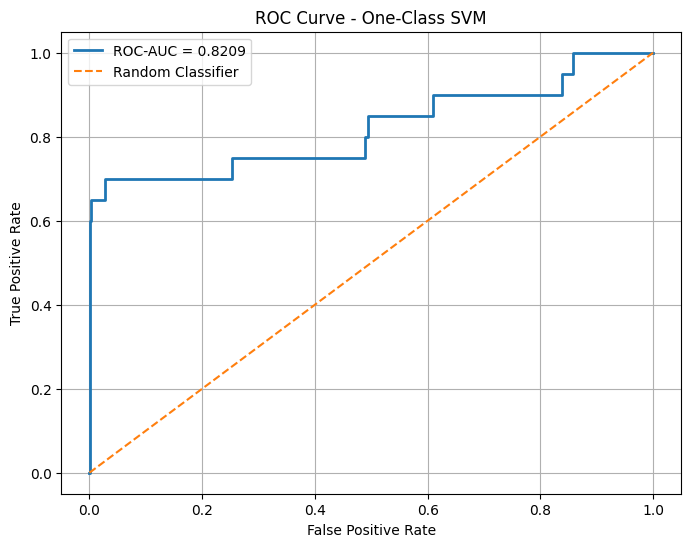

In [ ]:
# ==============================
# ROC Curve Visualization
# ==============================

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(
    y_test,
    anomaly_scores)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC-AUC = {roc_auc:.4f}")

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier")

# Plot formatting
plt.title("ROC Curve - One-Class SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

**ROC-AUC Insight:**  
The ROC curve shows that the One-Class SVM model performed significantly better than a random classifier, as the curve stays above the diagonal reference line.
The ROC-AUC score of 0.8209 indicates good anomaly detection capability and demonstrates that the model was reasonably effective in distinguishing between normal and fraudulent transactions after parameter and threshold tuning.

# Visualization

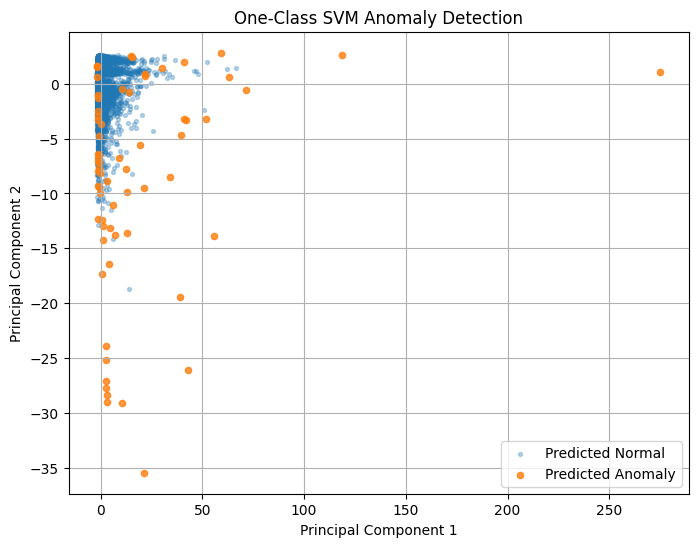

In [ ]:
# ==============================
# One-Class SVM Anomaly Visualization
# ==============================

# Visualize predictions using the first two PCA components

plt.figure(figsize=(8, 6))

# Predicted normal transactions
plt.scatter(
    X_test[y_pred == 0, 0],
    X_test[y_pred == 0, 1],
    s=8,
    alpha=0.3,
    label="Predicted Normal"
)

# Predicted anomalous transactions
plt.scatter(
    X_test[y_pred == 1, 0],
    X_test[y_pred == 1, 1],
    s=20,
    alpha=0.8,
    label="Predicted Anomaly"
)

# Plot formatting
plt.title("One-Class SVM Anomaly Detection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

**One-Class SVM Visualization Insight:**  
The visualization shows the distribution of predicted normal and anomalous transactions using the first two PCA components.

Most normal transactions are concentrated in dense regions near the center of the feature space, while many predicted anomalies appear farther from the main data distribution. This indicates that the One-Class SVM model was able to identify unusual transaction patterns that differ from normal behavior.

# 6. Deep Learning with TensorFlow and Keras

 6.1 Prepare Data

In [ ]:
# Verify data dimensions and inspect the class distribution.

print("X_scaled shape:", X_scaled.shape)
print("y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)

print("Class distribution:")
for label, count in zip(unique, counts):
    print(label, ":", count)

X_scaled shape: (283726, 30)
y shape: (283726,)
Class distribution:
0 : 283253
1 : 473


6.2 Separate Normal and Fraud Transactions

In [ ]:
# Separate normal and fraudulent transactions based on the class labels.

X_normal = X_scaled[y == 0]
X_fraud = X_scaled[y == 1]

print("Normal transactions shape:", X_normal.shape)
print("Fraud transactions shape:", X_fraud.shape)

Normal transactions shape: (283253, 30)
Fraud transactions shape: (473, 30)


6.3 Prepare Training and Validation Data

In [ ]:
# Split normal transactions into training and validation sets.

from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)

Training data shape: (226602, 30)
Validation data shape: (56651, 30)


6.4 Build Autoencoder Architecture

In [ ]:
# Build the Autoencoder architecture using TensorFlow and Keras.
# The model learns to reconstruct normal transactions.

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout

input_dim = X_train.shape[1]

# Input layer
input_layer = Input(shape=(input_dim,), name="input_layer")

# Encoder
encoded = Dense(16, activation="relu", name="encoder_layer_1")(input_layer)
encoded = Dropout(0.1, name="dropout_layer")(encoded)
latent_space = Dense(8, activation="relu", name="latent_space")(encoded)

# Decoder
decoded = Dense(16, activation="relu", name="decoder_layer_1")(latent_space)
output_layer = Dense(input_dim, activation="linear", name="output_layer")(decoded)

# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Compile model
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer_1 (Dense)         │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_layer_1 (Dense)         │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

6.5 Train the Autoencoder Model

In [ ]:
# Train the Autoencoder model using only normal transactions.

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

Epoch 1/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.7277 - val_loss: 0.4961
Epoch 2/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5013 - val_loss: 0.4127
Epoch 3/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.4527 - val_loss: 0.3783
Epoch 4/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4339 - val_loss: 0.3602
Epoch 5/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4174 - val_loss: 0.3585
Epoch 6/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4050 - val_loss: 0.3377
Epoch 7/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3953 - val_loss: 0.3447
Epoch 8/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3891 - val_loss: 0.3221
Epoch 9/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3815 - val_loss: 0.3141
Epoch 10/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3749 - val_loss: 0.3180
Epoch 11/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3717 - val_loss: 0.3118
Epoch 12/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step

The model used EarlyStopping, so training may stop before 30 epochs when the validation loss stops improving. This helps prevent overfitting and keeps the best model weights.

6.6 Loss Curves

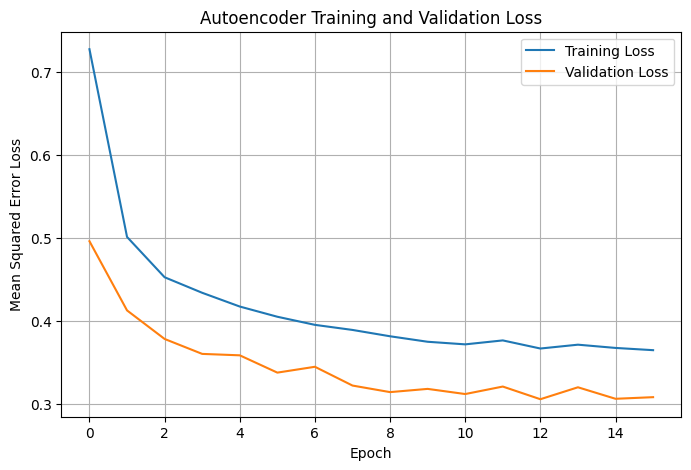

In [ ]:
# Visualize the Autoencoder training and validation loss.

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.title("Autoencoder Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

**Loss Curve Insight:**  
The training and validation losses decreased over the epochs, indicating that the Autoencoder learned to reconstruct normal transaction patterns effectively. The validation loss remained stable and close to the training loss, showing that the model did not suffer from clear overfitting.

6.7 Reconstruction Error and Thresholding

In [ ]:
# Prepare the test set by combining validation normal transactions with fraud transactions.

X_test = np.concatenate([X_val, X_fraud], axis=0)

y_test = np.concatenate([
    np.zeros(len(X_val)),
    np.ones(len(X_fraud))
], axis=0)

print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

unique_test, counts_test = np.unique(y_test, return_counts=True)

print("Test class distribution:")
for label, count in zip(unique_test, counts_test):
    print(label, ":", count)

Test data shape: (57124, 30)
Test labels shape: (57124,)
Test class distribution:
0.0 : 56651
1.0 : 473


In [ ]:
# Calculate reconstruction error for each transaction.

X_test_pred = autoencoder.predict(X_test)

reconstruction_error = np.mean(
    np.square(X_test - X_test_pred),
    axis=1
)

print("Reconstruction error shape:", reconstruction_error.shape)
print("Minimum error:", reconstruction_error.min())
print("Maximum error:", reconstruction_error.max())
print("Mean error:", reconstruction_error.mean())

1786/1786 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Reconstruction error shape: (57124,)
Minimum error: 0.02607740629882246
Maximum error: 85.23285041996743
Mean error: 0.43924445275407203


In [ ]:
# Select a threshold and classify transactions as normal or anomalous.
# Transactions with reconstruction error above the threshold are classified as anomalies.

threshold = np.percentile(reconstruction_error, 99)

print("Selected threshold:", threshold)

y_pred = (reconstruction_error > threshold).astype(int)

print("Predicted class distribution:")
unique_pred, counts_pred = np.unique(y_pred, return_counts=True)

for label, count in zip(unique_pred, counts_pred):
    print(label, ":", count)

Selected threshold: 3.0204523384874142
Predicted class distribution:
0 : 56552
1 : 572


6.8 Model Evaluation

In [ ]:
# Evaluate the Autoencoder anomaly detection performance.

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Fraud"],
    zero_division=0
))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, reconstruction_error)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

Confusion Matrix:
[[56421   230]
 [  131   342]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.60      0.72      0.65       473

    accuracy                           0.99     57124
   macro avg       0.80      0.86      0.83     57124
weighted avg       0.99      0.99      0.99     57124

Accuracy: 0.9937
Precision: 0.5979
Recall: 0.723
F1-Score: 0.6545
ROC-AUC: 0.9473


**Autoencoder Evaluation Insight:**  
The Autoencoder achieved strong anomaly detection performance with a ROC-AUC score of 0.9473. It detected 342 out of 473 fraud cases, achieving a fraud recall of 0.723. Compared with One-Class SVM, the Autoencoder provided a better balance between detecting fraud and reducing false alarms, as shown by the higher precision and F1-score.

6.9 Reconstruction Error Visualization

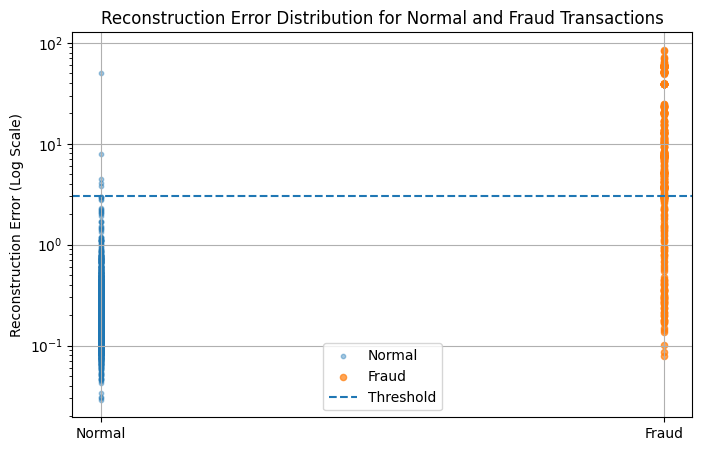

In [ ]:
# Visualize reconstruction errors for normal and fraudulent transactions.

normal_errors = reconstruction_error[y_test == 0]
fraud_errors = reconstruction_error[y_test == 1]

np.random.seed(42)

normal_sample_size = min(2000, len(normal_errors))
normal_sample = np.random.choice(
    normal_errors,
    size=normal_sample_size,
    replace=False
)

x_normal = np.zeros(len(normal_sample))
x_fraud = np.ones(len(fraud_errors))

plt.figure(figsize=(8, 5))

plt.scatter(
    x_normal,
    normal_sample,
    alpha=0.4,
    s=10,
    label="Normal"
)

plt.scatter(
    x_fraud,
    fraud_errors,
    alpha=0.7,
    s=20,
    label="Fraud"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Threshold"
)

plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yscale("log")
plt.ylabel("Reconstruction Error (Log Scale)")
plt.title("Reconstruction Error Distribution for Normal and Fraud Transactions")
plt.legend()
plt.grid(True)
plt.show()

6.10 Learned Latent Representations

1786/1786 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
Latent representation shape: (57124, 8)


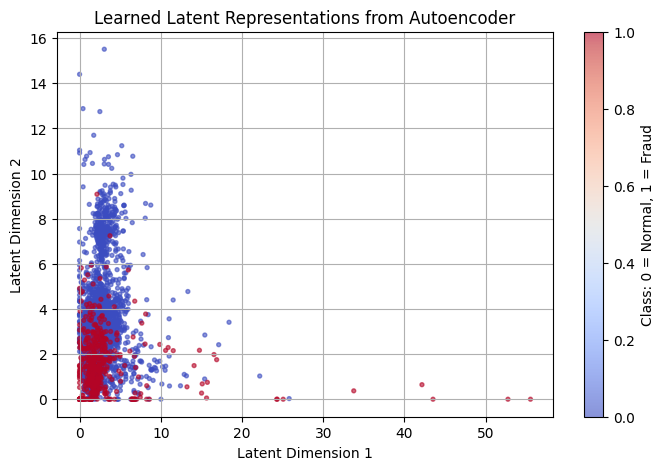

In [ ]:
# Extract and visualize the learned latent representations from the Autoencoder.

encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent_space").output
)

X_test_latent = encoder.predict(X_test)

print("Latent representation shape:", X_test_latent.shape)

normal_idx = np.where(y_test == 0)[0]
fraud_idx = np.where(y_test == 1)[0]

normal_sample_size = min(5000, len(normal_idx))
normal_sample_idx = np.random.choice(
    normal_idx,
    size=normal_sample_size,
    replace=False
)

plot_idx = np.concatenate([normal_sample_idx, fraud_idx])

plt.figure(figsize=(8, 5))

scatter = plt.scatter(
    X_test_latent[plot_idx, 0],
    X_test_latent[plot_idx, 1],
    c=y_test[plot_idx],
    s=8,
    alpha=0.6,
    cmap="coolwarm"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Learned Latent Representations from Autoencoder")
plt.colorbar(scatter, label="Class: 0 = Normal, 1 = Fraud")
plt.grid(True)
plt.show()

**Latent Representation Insight:**  
The plot shows that the Autoencoder was able to learn useful hidden patterns from the transaction data. Some fraud transactions appear separated from normal transactions, which supports the model’s ability to detect anomalies. However, some overlap remains between normal and fraud cases, meaning that fraud detection is challenging because some fraudulent transactions behave similarly to normal ones.

# 7. Final Model Comparison

After testing the models, we summarized the main results to see which method worked better.

## Clustering Evaluation

| Model | Silhouette Score | Davies-Bouldin Index | Noise Points | Interpretation |
|---|---:|---:|---:|---|
| DBSCAN without PCA | 0.0415 | 1.3028 | 2801 | Weak clustering separation |
| DBSCAN with PCA | 0.6660 | 0.6302 | 575 | Better clustering quality after PCA |

DBSCAN with PCA performed better because PCA reduced dimensionality and helped DBSCAN form clearer clusters with fewer noise points.

## Anomaly Detection Evaluation

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| One-Class SVM | - | 0.06 | 0.80 | 0.11 | 0.9067 |
| Autoencoder | 0.9937 | 0.5979 | 0.723 | 0.6545 | 0.9473 |

The Autoencoder achieved the best overall performance because it had the highest ROC-AUC score and a better balance between precision, recall, and F1-score. Although One-Class SVM achieved high recall, its precision was low, meaning it produced more false alarms. DBSCAN was mainly useful for clustering and noise detection rather than direct fraud classification.

# 8. Conclusion

In this project, we worked on detecting anomalies in credit card transactions using unsupervised machine learning and deep learning methods. The dataset was highly imbalanced, where most transactions were normal and only a small number were fraud cases.

We first cleaned and prepared the data, then used PCA and t-SNE to reduce dimensions and visualize the data. The visualizations showed that normal and fraud transactions overlap, which makes fraud detection more difficult.

For clustering, DBSCAN was useful for finding clusters and noise points, especially after using PCA. For anomaly detection, One-Class SVM was able to detect many fraud cases, but it also produced many false alarms. The Autoencoder gave the best overall results because it had the highest ROC-AUC score and a better balance between precision, recall, and F1-score.

Overall, the Autoencoder was the most effective model in our project for detecting anomalous credit card transactions.